## Libraries & packages

In [6]:
#| echo: true

# Standard library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
from IPython.display import display, Math

# Third-party imports
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List, Any
from textwrap import dedent
import patsy
import textwrap
import pymc as pm
import arviz as az

# Statsmodels imports
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF
from statsmodels.tools.sm_exceptions import PerfectSeparationError

# Sklearn imports
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample

# Set global configurations
np.random.seed(42)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## Air Quality Data Dictionary:

**Source:** UCI Machine Learning Repository (ID: 360)  
**Records:** 9,357 hourly observations | **Period:** March 2004 - February 2005  
**Missing values:** Tagged as `-200` in the original data

---

### Index Variables

1. **Date**
   - Date of recording
   - Type: Date (DD/MM/YYYY)
   - Modeling note: Combined with Time to create Datetime index

2. **Time**
   - Hour of recording
   - Type: Categorical (HH.MM.SS)
   - Modeling note: Combined with Date to create Datetime index

---

### Response Variables -- Sensor Readings

3. **PT08.S1(CO)**
   - Hourly averaged tin oxide sensor response, nominally CO targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 1; measures sensor estimation capability for CO; 3.9% missing (-200)

4. **PT08.S2(NMHC)**
   - Hourly averaged titania sensor response, nominally NMHC targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 2; measures sensor estimation capability for NMHC; 3.9% missing (-200)

5. **PT08.S3(NOx)**
   - Hourly averaged tungsten oxide sensor response, nominally NOx targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 3; measures sensor estimation capability for NOx; 3.9% missing (-200)

6. **PT08.S4(NO2)**
   - Hourly averaged tungsten oxide sensor response, nominally NO2 targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 4; measures sensor estimation capability for NO2; 3.9% missing (-200)

7. **PT08.S5(O3)**
   - Hourly averaged indium oxide sensor response, nominally O3 targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 5; measures sensor estimation capability for O3; 3.9% missing (-200)

---

### Predictor Variables -- True Pollutant Concentrations (Reference Analyzer)

8. **CO(GT)**
   - True hourly averaged concentration of Carbon Monoxide
   - Type: Integer (Continuous)
   - Units: mg/m3
   - Modeling note: Ground truth predictor for PT08.S1(CO); 18.0% missing (-200)

9. **NMHC(GT)**
   - True hourly averaged overall Non-Metanic Hydrocarbons concentration
   - Type: Integer (Continuous)
   - Units: microg/m3
   - Modeling note: Ground truth predictor for PT08.S2(NMHC); **90.2% missing** -- likely excluded from modeling

10. **C6H6(GT)**
    - True hourly averaged Benzene concentration
    - Type: Continuous
    - Units: microg/m3
    - Modeling note: Ground truth predictor; 3.9% missing (-200)

11. **NOx(GT)**
    - True hourly averaged Total Nitrogen Oxides concentration
    - Type: Integer (Continuous)
    - Units: ppb
    - Modeling note: Ground truth predictor for PT08.S3(NOx); 17.5% missing (-200)

12. **NO2(GT)**
    - True hourly averaged Nitrogen Dioxide concentration
    - Type: Integer (Continuous)
    - Units: microg/m3
    - Modeling note: Ground truth predictor for PT08.S4(NO2); 17.6% missing (-200)

---

### Predictor Variables -- Environmental Conditions

13. **T**
    - Ambient temperature at time of recording
    - Type: Continuous
    - Units: Celsius (C)
    - Modeling note: Environmental covariate; evidence of cross-sensitivity with sensors; 3.9% missing (-200)

14. **RH**
    - Relative humidity at time of recording
    - Type: Continuous
    - Units: %
    - Modeling note: Environmental covariate; may affect sensor drift; 3.9% missing (-200)

15. **AH**
    - Absolute humidity at time of recording
    - Type: Continuous
    - Units: --
    - Modeling note: Correlated with RH and T; check for multicollinearity before modeling; 3.9% missing (-200)

## Data Source & Import:
Source: https://archive.ics.uci.edu/dataset/360/air+quality

Load dataset for Air Quality from UC Irvine Machine Learning Repository.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [43]:
# Build master dataframe from features
df_air = air_quality.data.features.copy()

print(f"df_air shape : {df_air.shape}")
df_air.head(10)

df_air shape : (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,3/11/2004,1:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,3/11/2004,2:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,3/11/2004,3:00:00,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


## Initialization

1. Create target variable
2. Create predictors variable
   - Drop Day and Time
5. Perform data validation
   - Deal with missing value

In [44]:
# Drop Day and Time
df_air.drop(columns=["Date", "Time"], inplace=True)

# Create response variables (sensor readings)
y_air = df_air[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                "PT08.S4(NO2)", "PT08.S5(O3)"]].copy()

# Create predictor variables
X_air = df_air.drop(
    columns=["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
             "PT08.S4(NO2)", "PT08.S5(O3)"]
).copy()

In [45]:
#| label: tbl-air-validation
#| tbl-cap: "Data validation for the Air Quality data: shapes, columns, and target distribution."
#| echo: false
#| tbl-pos: H
print("X_air:", X_air.shape)
print("y_air:", y_air.shape)
print("df_air:", df_air.shape)
cols_str = ", ".join(map(str, df_air.columns))
wrapped = textwrap.fill(cols_str, width=80)
print("df_air columns: " + wrapped)
print(y_air.describe())
df_air.head(10)

X_air: (9357, 8)
y_air: (9357, 5)
df_air: (9357, 13)
df_air columns: CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx),
NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH
       PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)
count  9357.000000    9357.000000   9357.000000   9357.000000  9357.000000
mean   1048.990061     894.595276    794.990168   1391.479641   975.072032
std     329.832710     342.333252    321.993552    467.210125   456.938184
min    -200.000000    -200.000000   -200.000000   -200.000000  -200.000000
25%     921.000000     711.000000    637.000000   1185.000000   700.000000
50%    1053.000000     895.000000    794.000000   1446.000000   942.000000
75%    1221.000000    1105.000000    960.000000   1662.000000  1255.000000
max    2040.000000    2214.000000   2683.000000   2775.000000  2523.000000


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


## Exploratory data analysis

### 1. Check missing values (Missing values are tagged with -200 value)

### Missing Value Analysis

#### Overview
The dataset contains a total of **16,701 missing values**, encoded as `-200`
in the original data. The missing values fall into three distinct patterns:

#### Pattern 1 -- Structural Blackout (3.91%)
All sensor readings and environmental variables (PT08.S1 through PT08.S5,
T, RH, AH, C6H6) share exactly **366 missing rows**.

#### Pattern 2 -- Moderate Missingness (~18%)
CO(GT), NOx(GT), and NO2(GT) have around 17-18% missing values.

#### Pattern 3 -- Severe Missingness (90.23%)
NMHC(GT) has **8,443 out of 9,357 rows** missing -- only 9.77% of values
are recorded.

---

#### Handling Strategy

**Step 1 -- Drop NMHC(GT)**
With 90.23% of values missing, NMHC(GT) was removed entirely from the dataset.

**Step 2 -- Replace -200 with NaN**
The value -200 is a placeholder tag, not a real measurement. It was
converted to NaN so that pandas can recognize it as a missing value.

**Step 3 -- Forward Fill (ffill)**
Since this dataset is an **hourly time-series**, each missing value is
replaced by the most recent valid observation, preserving the temporal
continuity of the data.

After applying these steps, **0 missing values** remain, with the final
dataset retaining all 9,357 rows across 7 predictors and 5 response variables.

In [46]:
#| label: tbl-air-missing-values
#| tbl-cap: "Missing value summary for the Air Quality dataset."

missing_summary = (df_air == -200).sum().to_frame("missing_count")
missing_summary["%_missing"] = (missing_summary["missing_count"] / len(df_air) * 100).round(2).astype(str) + "%"

missing_values_table = pd.DataFrame({
    "Metric": ["Total missing values (-200)"],
    "Value": [(df_air == -200).sum().sum()]
})

display(missing_values_table)
display(missing_summary)

,Metric,Value
0,Total missing values (-200),16701


,missing_count,%_missing
CO(GT),1683,17.99%
PT08.S1(CO),366,3.91%
NMHC(GT),8443,90.23%
C6H6(GT),366,3.91%
PT08.S2(NMHC),366,3.91%
NOx(GT),1639,17.52%
PT08.S3(NOx),366,3.91%
NO2(GT),1642,17.55%
PT08.S4(NO2),366,3.91%
PT08.S5(O3),366,3.91%


In [47]:
# Drop NMHC(GT) — 90.2% missing, unusable
df_air.drop(columns=["NMHC(GT)"], inplace=True)

# Replace -200 with NaN
df_air.replace(-200, np.nan, inplace=True)

# Forward fill — respects time-series structure
df_air.ffill(inplace=True)

print(f"Remaining missing: {df_air.isna().sum().sum()}")

# Update y_air and X_air after cleaning
y_air = df_air[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                "PT08.S4(NO2)", "PT08.S5(O3)"]].copy()

X_air = df_air.drop(
    columns=["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
             "PT08.S4(NO2)", "PT08.S5(O3)"]
).copy()

print(f"y_air shape : {y_air.shape}")
print(f"X_air shape : {X_air.shape}")

Remaining missing: 0
y_air shape : (9357, 5)
X_air shape : (9357, 7)


### 2. Descriptive Statistics

In [51]:
#| label: tbl-air-descriptive
#| tbl-cap: "Descriptive statistics for the Air Quality dataset."

desc = df_air.describe().T[["mean", "std", "min", "max"]]
desc = desc.round(3)
display(desc)

,mean,std,min,max
CO(GT),2.082,1.470,0.100,11.900
PT08.S1(CO),1102.730,219.588,647.000,2040.000
C6H6(GT),10.190,7.566,0.100,63.700
PT08.S2(NMHC),942.548,269.581,383.000,2214.000
NOx(GT),240.731,206.618,2.000,1479.000
PT08.S3(NOx),832.742,255.709,322.000,2683.000
NO2(GT),109.415,47.222,2.000,340.000
PT08.S4(NO2),1453.015,347.434,551.000,2775.000
PT08.S5(O3),1030.512,410.917,221.000,2523.000
T,18.317,8.822,-1.900,44.600


### 3. Distributions of targets

Task was destroyed but it is pending!
task: <Task pending name='Task-216' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\33135\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-217' coro=<Kernel.shell_main() running at C:\Users\33135\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\33135\AppData\Local\Programs\Python\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\33135\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\transforms.py:195: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-217' coro=<Kernel.shell_main() running at C:\Users\33135\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> 

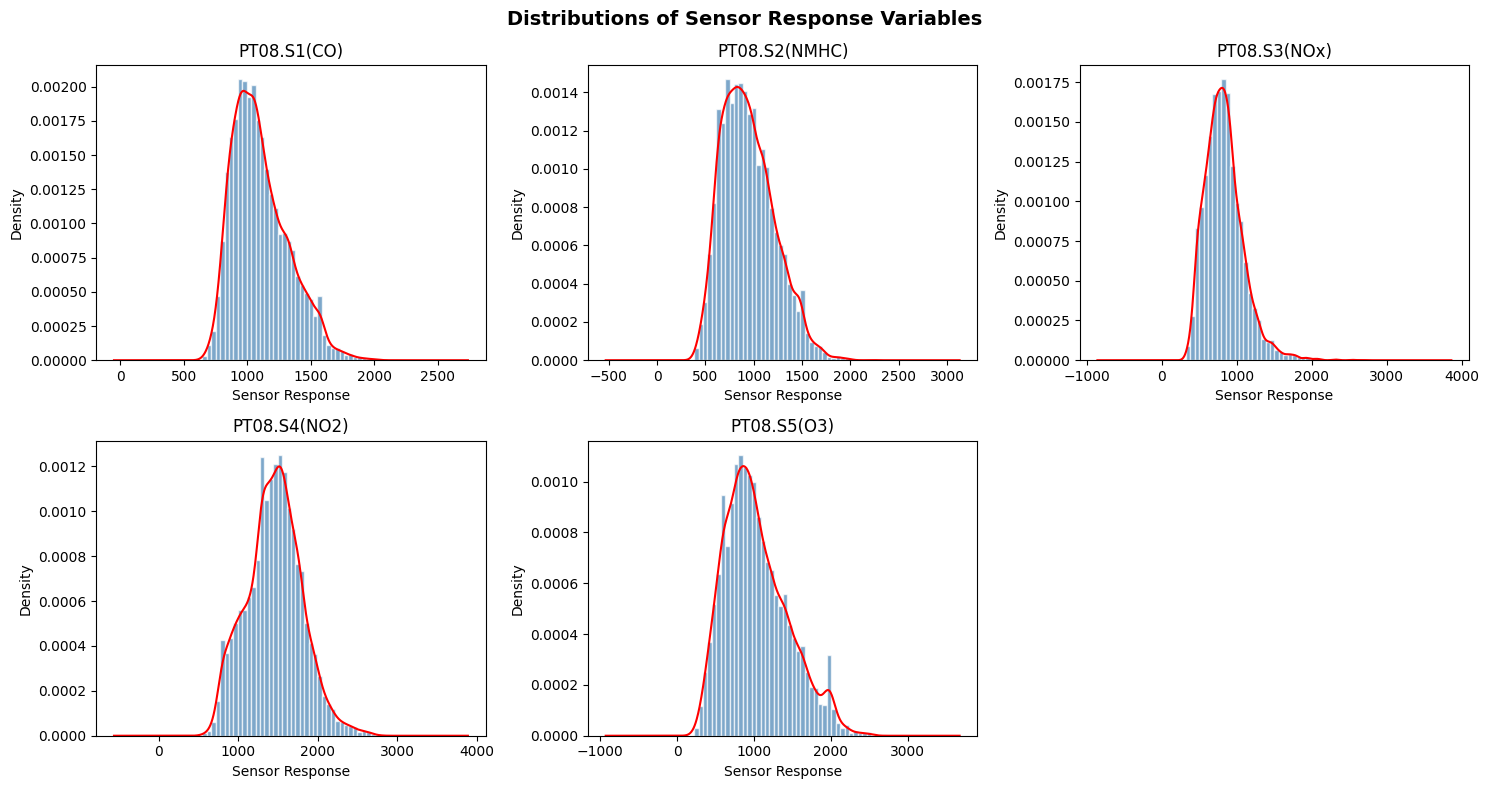

In [50]:
#| label: fig-air-distributions
#| fig-cap: "Distributions of sensor response variables."

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

response_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                 "PT08.S4(NO2)", "PT08.S5(O3)"]

for i, col in enumerate(response_cols):
    axes[i].hist(df_air[col], bins=40, color="steelblue", edgecolor="white", 
                 alpha=0.7, density=True)
    df_air[col].plot.kde(ax=axes[i], color="red", linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Sensor Response")
    axes[i].set_ylabel("Density")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Distributions of Sensor Response Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4. Distributions of predictors

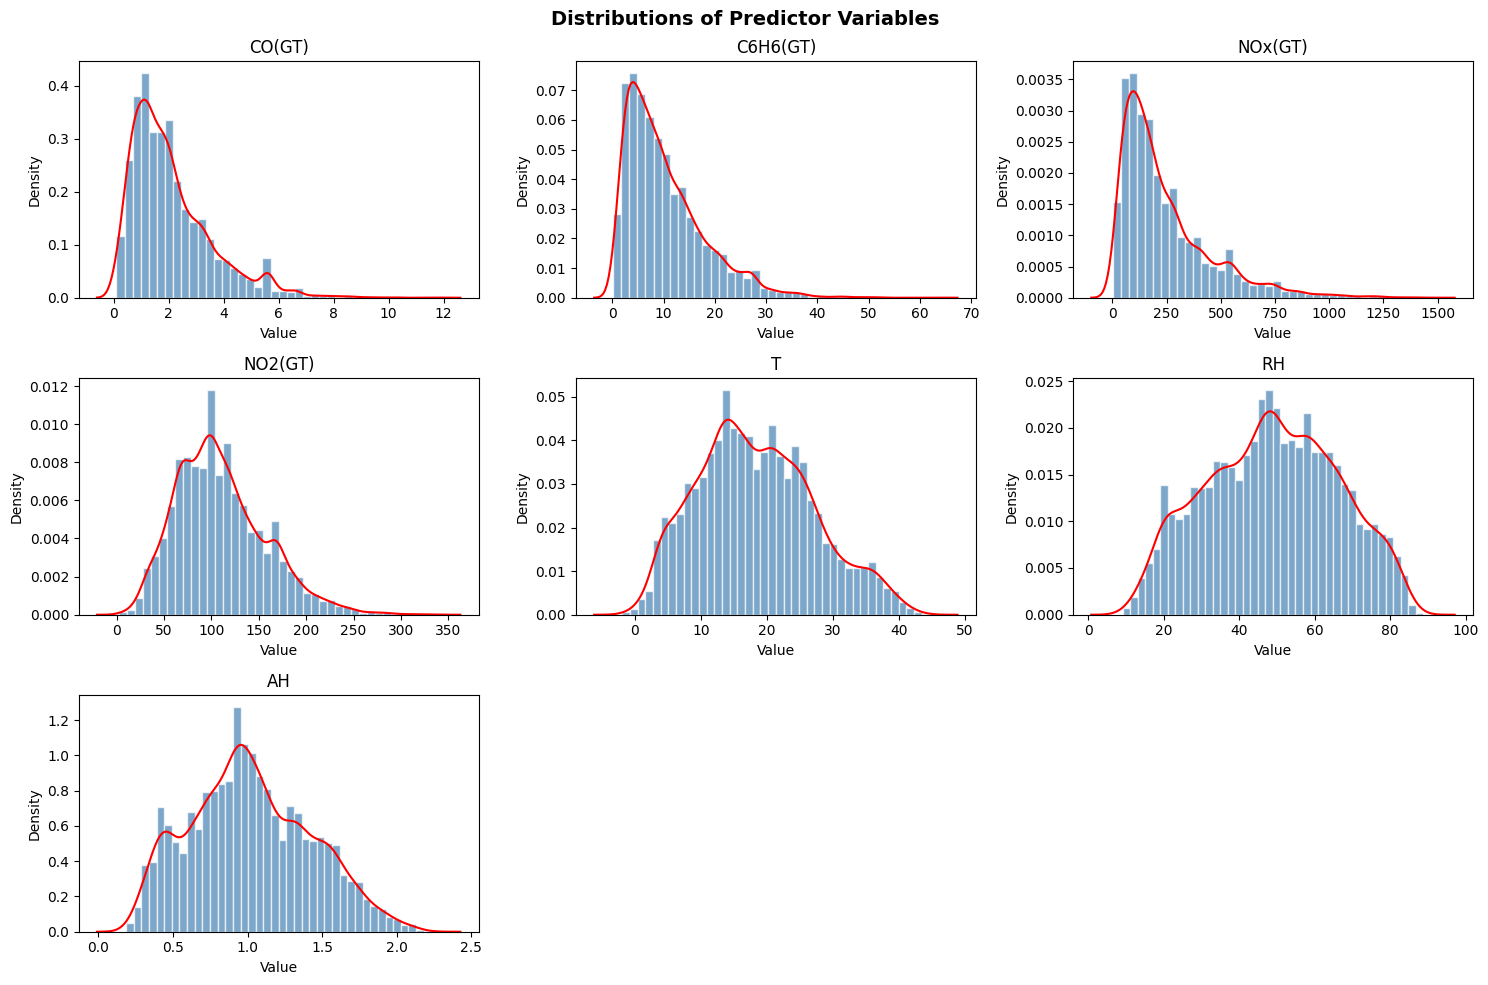

In [52]:
#| label: fig-air-predictor-distributions
#| fig-cap: "Distributions of predictor variables."

predictor_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", 
                  "T", "RH", "AH"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(predictor_cols):
    axes[i].hist(df_air[col], bins=40, color="steelblue", edgecolor="white",
                 alpha=0.7, density=True)
    sns.kdeplot(df_air[col], ax=axes[i], color="red", linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

# Hide empty subplots
for j in range(len(predictor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Predictor Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 5. Correlation

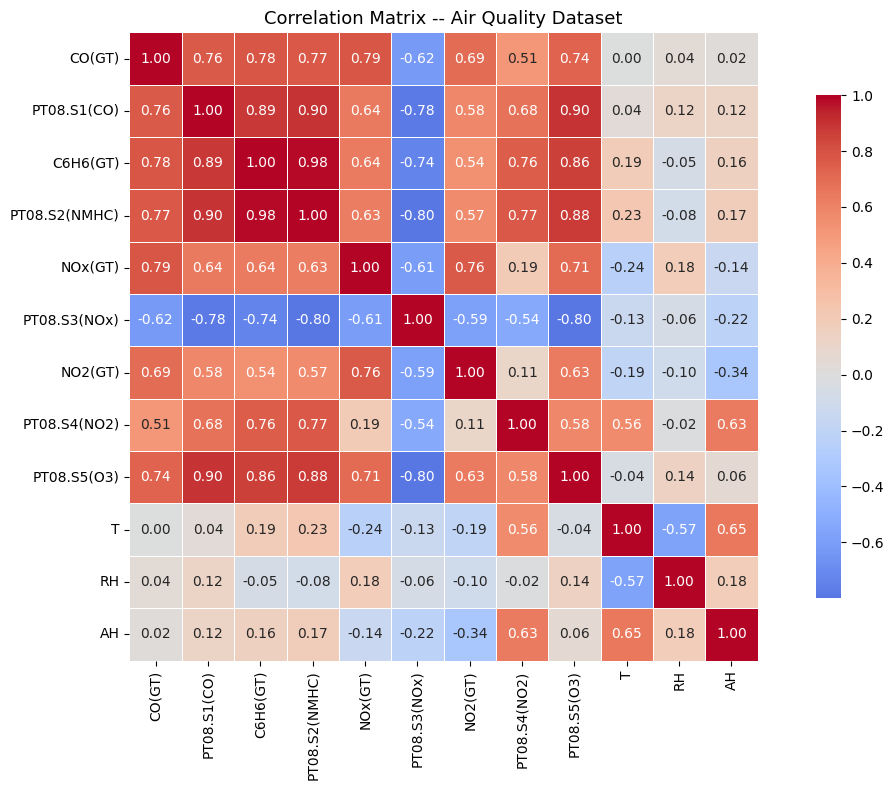

In [49]:
#| label: fig-air-correlation
#| fig-cap: "Correlation heatmap for the Air Quality dataset."

plt.figure(figsize=(12, 8))
corr = df_air.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix -- Air Quality Dataset", fontsize=13)
plt.tight_layout()
plt.show()

### 6. Scatter plots 

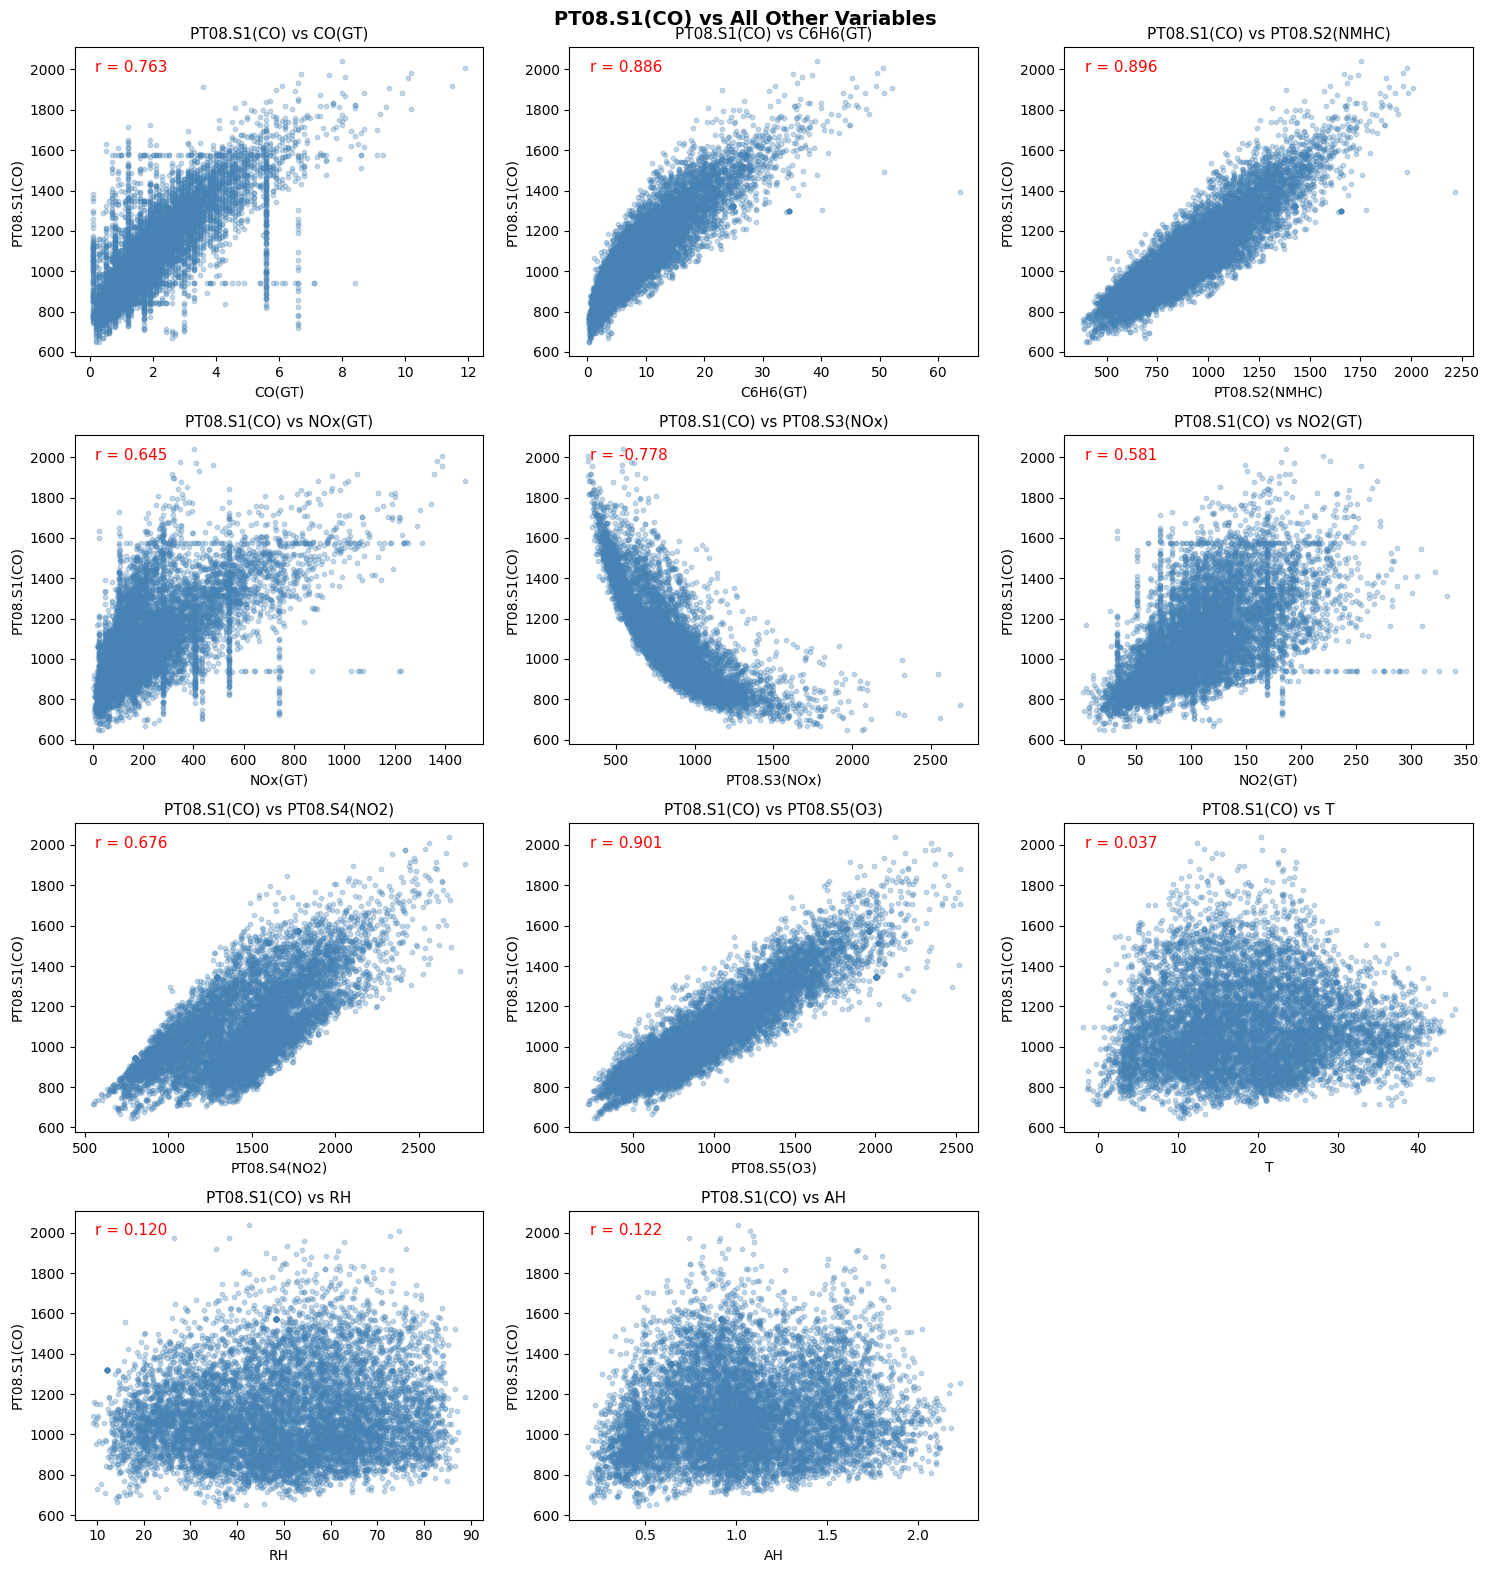

In [56]:
#| label: fig-air-scatter-s1
#| fig-cap: "Scatter plots of PT08.S1(CO) vs all other variables."

other_cols = [col for col in df_air.columns if col != "PT08.S1(CO)"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(other_cols):
    axes[i].scatter(df_air[col], df_air["PT08.S1(CO)"],
                    alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("PT08.S1(CO)")
    axes[i].set_title(f"PT08.S1(CO) vs {col}", fontsize=11)
    corr_val = df_air[[col, "PT08.S1(CO)"]].corr().iloc[0, 1]
    axes[i].annotate(f"r = {corr_val:.3f}", xy=(0.05, 0.92),
                     xycoords="axes fraction", fontsize=11, color="red")

# Hide empty subplots
for j in range(len(other_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("PT08.S1(CO) vs All Other Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()